In [1]:
# ==============================================================
# Libraries
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import treecorr
import os

In [2]:
# ==============================================================
# Utility Functions
# ==============================================================

def load_frb_catalog(filepath):
    """
    Load FRB catalog and apply basic validation cuts.
    """
    df = pd.read_csv(filepath)
    df = df[["RA", "DEC"]].dropna()
    valid = (df["RA"] >= 0) & (df["RA"] < 360) & (df["DEC"] >= -90) & (df["DEC"] <= 90)
    return df[valid].reset_index(drop=True)


# ==============================================================
# Catalog Generators (Isotropic and Dipolar)
# ==============================================================

def generate_catalog(n_sources, A=0.0, direction=(0, 0), seed=None):
    """
    Generates a sky catalog of point sources.

    For A=0, sources are distributed isotropically over the full sphere.
    For A>0, a dipole anisotropy is injected via rejection sampling, where
    the acceptance probability follows P(n) ∝ 1 + A*(n · d), with d being
    the unit vector along the dipole direction.

    Parameters
    ----------
    n_sources : int
        Number of sources to generate.
    A : float
        Dipole amplitude. 0 = isotropic, >0 = anisotropic.
    direction : tuple (ra_deg, dec_deg)
        Sky direction of the dipole axis in degrees.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    pd.DataFrame with columns ['RA', 'DEC'] in degrees.
    """
    
    rng = np.random.default_rng(seed)

    # --- Isotropic case: direct sampling ---
    # RA is uniform in [0, 360); DEC is drawn from arcsin(uniform) to ensure
    # uniform area coverage on the sphere.
    if A == 0:
        ra  = 360.0 * rng.random(n_sources)
        dec = np.degrees(np.arcsin(2.0 * rng.random(n_sources) - 1.0))
        return pd.DataFrame({"RA": ra, "DEC": dec})

    # --- Dipole case: rejection sampling ---
    # Convert dipole direction to a Cartesian unit vector.
    ra_d, dec_d = np.deg2rad(direction)
    d = np.array([
        np.cos(dec_d) * np.cos(ra_d),
        np.cos(dec_d) * np.sin(ra_d),
        np.sin(dec_d)
    ])

    ra_out, dec_out = [], []

    while len(ra_out) < n_sources:
        # Draw a candidate point uniformly on the sphere.
        ra_try  = 360.0 * rng.random()
        dec_try = np.degrees(np.arcsin(2.0 * rng.random() - 1.0))

        # Convert candidate to a Cartesian unit vector.
        phi = np.deg2rad(ra_try)
        theta = np.deg2rad(dec_try)
        n = np.array([
            np.cos(theta) * np.cos(phi),
            np.cos(theta) * np.sin(phi),
            np.sin(theta)
        ])

        # Acceptance probability: normalized so that p <= 1 for all directions.
        # Dividing by (1 + |A|) guarantees the maximum of P(n) is exactly 1.
        p = (1.0 + A * np.dot(n, d)) / (1.0 + abs(A))

        if rng.random() < p:
            ra_out.append(ra_try)
            dec_out.append(dec_try)

    return pd.DataFrame({"RA": ra_out, "DEC": dec_out})


# ==============================================================
# 2pACF Calculation via TreeCorr (Landy-Szalay Estimator)
# ==============================================================

def get_2pacf(df_data, df_rand, min_sep=0.1, max_sep=180.0, nbins=20):
    """
    Computes the Angular Two-Point Correlation Function (2pACF) using the
    Landy-Szalay estimator: w(θ) = (DD - 2*DR + RR) / RR.

    TreeCorr handles all pair counting and internal normalization, accounting
    for the ratio N_data / N_rand automatically.

    Parameters
    ----------
    df_data : pd.DataFrame
        Observed catalog with columns ['RA', 'DEC'].
    df_rand : pd.DataFrame
        Random (unclustered) reference catalog with columns ['RA', 'DEC'].
    min_sep : float
        Minimum angular separation in degrees.
    max_sep : float
        Maximum angular separation in degrees.
    nbins : int
        Number of logarithmic angular bins.

    Returns
    -------
    theta : np.ndarray
        Angular bin centers in degrees (geometric mean of log bins).
    xi : np.ndarray
        Correlation function values w(θ).
    """
    
    # Build TreeCorr catalogs from RA/DEC columns.
    cat = treecorr.Catalog(
        ra=df_data["RA"], dec=df_data["DEC"],
        ra_units="deg", dec_units="deg"
    )
    rnd = treecorr.Catalog(
        ra=df_rand["RA"], dec=df_rand["DEC"],
        ra_units="deg", dec_units="deg"
    )

    # TreeCorr's default bin_slop is intentional and statistically correct —
    # it must not be altered. Fixed geometric centers are used instead (see return).
    config = dict(min_sep=min_sep, max_sep=max_sep, nbins=nbins, sep_units="deg")
    nn = treecorr.NNCorrelation(**config)
    rr = treecorr.NNCorrelation(**config)
    dr = treecorr.NNCorrelation(**config)

    # Count pairs: data-data, random-random, and data-random.
    nn.process(cat)
    rr.process(rnd)
    dr.process(cat, rnd)

    # Apply the Landy-Szalay estimator. TreeCorr normalizes DD, RR, DR
    # by their respective pair counts, so catalog sizes need not be equal.
    nn.calculateXi(rr=rr, dr=dr)

    # Return fixed geometric bin centers instead of exp(meanlogr).
    # meanlogr is the mean of log(sep) over actual pairs in each bin, so it
    # shifts slightly between catalogs due to TreeCorr's bin_slop — which is
    # statistically correct and must not be suppressed.
    # The fixed centers below are purely a function of the bin configuration
    # and are identical for every catalog, giving a stable shared x-axis.
    log_edges   = np.linspace(np.log(min_sep), np.log(max_sep), nbins + 1)
    theta_fixed = np.exp(0.5 * (log_edges[:-1] + log_edges[1:]))
    return theta_fixed, nn.xi


# ==============================================================
# Absolute Sum Test with Linear Rebinning
# ==============================================================

def get_absolute_sum_bins(theta, w, bin_edges):
    """
    Compresses the noisy 2pACF into a scalar per wide angular bin.

    For each bin, the mean of w(θ) is computed (rebinning reduces noise),
    and its absolute value is taken. Under isotropy (H0), the mean should
    be ~0; a large |<w>| signals anisotropy at that angular scale.

    Parameters
    ----------
    theta : np.ndarray
        Angular bin centers from the 2pACF (degrees).
    w : np.ndarray
        Correlation function values w(θ).
    bin_edges : np.ndarray
        Edges of the wide linear bins (e.g., [0, 20, 40, ..., 180]).

    Returns
    -------
    np.ndarray
        Absolute mean correlation per wide bin.
    """

    abs_vals = []

    for i in range(len(bin_edges) - 1):
        # Select 2pACF points that fall within this wide bin.
        mask = (theta >= bin_edges[i]) & (theta < bin_edges[i + 1])

        if np.any(mask):
            # Mean over the bin suppresses random fluctuations; |...| measures
            # deviation from the isotropy expectation of zero.
            abs_vals.append(np.abs(np.mean(w[mask])))
        else:
            abs_vals.append(0.0)  # Empty bin: contributes nothing.

    return np.array(abs_vals)

In [9]:
# ==============================================================
# Configuration
# ==============================================================

BASE_PATH = "/home/brunowesley/projetos/FRB-isotropy-tests/FRB_catalogs/"
NORTH_PATHS = [os.path.join(BASE_PATH, f"SkyPosition_North{i}.csv") for i in range(1, 16)]
SOUTH_PATH = os.path.join(BASE_PATH, "SkyPosition_South.csv")

COARSE_BINS = np.arange(0, 181, 20)
COARSE_CENTERS = 0.5 * (COARSE_BINS[:-1] + COARSE_BINS[1:])
N_RAND_FACTOR = 20

# Storage
all_w_obs = []
all_abs_obs = []

# ==============================================================
# Load South once
# ==============================================================

frb_south = load_frb_catalog(SOUTH_PATH)

# Pre-compute global DEC limits (minimal observational constraint)
all_dec = []

for path in NORTH_PATHS:
    df_tmp = load_frb_catalog(path)
    all_dec.extend(df_tmp["DEC"].values)

all_dec.extend(frb_south["DEC"].values)

DEC_MIN = np.min(all_dec)
DEC_MAX = np.max(all_dec)

print(f"Using DEC range for isotropic mocks: [{DEC_MIN:.2f}, {DEC_MAX:.2f}]")

# ==============================================================
# 1. Individual Ensembles (REAL DATA)
# ==============================================================

print("--- Processing 15 Ensembles (REAL DATA) ---")

for i, path in enumerate(NORTH_PATHS):

    frb_north = load_frb_catalog(path)

    # Combine North + South data
    df_mixed = pd.concat([frb_north, frb_south], ignore_index=True)

    # ----------------------------------------------------------
    # Random catalog (PURE ISOTROPY within DEC limits)
    # ----------------------------------------------------------
    
    df_rand = generate_catalog(
        len(df_mixed) * N_RAND_FACTOR,
        A=0.0,
        seed=1000 + i
    )

    # Apply DEC cut (minimal observational constraint)
    df_rand = df_rand[(df_rand["DEC"] >= DEC_MIN) & (df_rand["DEC"] <= DEC_MAX)].reset_index(drop=True)

    # ----------------------------------------------------------
    # Compute correlation
    # ----------------------------------------------------------

    theta, w = get_2pacf(df_mixed, df_rand)
    abs_sum = get_absolute_sum_bins(theta, w, COARSE_BINS)

    all_w_obs.append(w)
    all_abs_obs.append(abs_sum)

    print(f"Subcatalog {i+1:2d}: Done.")

# Convert to arrays
all_w_obs = np.array(all_w_obs)
all_abs_obs = np.array(all_abs_obs)

# ==============================================================
# 2. Mean statistics
# ==============================================================

mean_w = np.mean(all_w_obs, axis=0)
mean_abs = np.mean(all_abs_obs, axis=0)

# ==============================================================
# 3. H0 Benchmark (PURE ISOTROPY - INDEPENDENT)
# ==============================================================

print("Generating PURE isotropic benchmark (independent H0)...")

w_h0_samples = []

# Use average number of sources
avg_n = int(np.mean([len(load_frb_catalog(p)) + len(frb_south) for p in NORTH_PATHS]))

for i in tqdm(range(100), desc="H0 Samples"):

    # ----------------------------------------------------------
    # Generate isotropic sky (NO DATA USED HERE)
    # ----------------------------------------------------------
    
    d_iso = generate_catalog(
        avg_n,
        A=0.0,
        seed=i
    )

    # Apply same DEC limits
    d_iso = d_iso[(d_iso["DEC"] >= DEC_MIN) & (d_iso["DEC"] <= DEC_MAX)].reset_index(drop=True)

    # ----------------------------------------------------------
    # Random catalog (also isotropic)
    # ----------------------------------------------------------
    
    r_iso = generate_catalog(
        len(d_iso) * N_RAND_FACTOR,
        A=0.0,
        seed=i + 1000
    )

    r_iso = r_iso[(r_iso["DEC"] >= DEC_MIN) & (r_iso["DEC"] <= DEC_MAX)].reset_index(drop=True)

    # ----------------------------------------------------------
    # Compute 2pACF
    # ----------------------------------------------------------
    
    _, w_h0 = get_2pacf(d_iso, r_iso)
    w_h0_samples.append(w_h0)

w_h0_samples = np.array(w_h0_samples)

h0_median = np.median(w_h0_samples, axis=0)
h0_std = np.std(w_h0_samples, axis=0)

# ==============================================================
# Absolute Sum Benchmark
# ==============================================================

abs_h0_samples = []

for w_h0 in w_h0_samples:
    abs_h0_samples.append(get_absolute_sum_bins(theta, w_h0, COARSE_BINS))

abs_h0_samples = np.array(abs_h0_samples)

abs_h0_median = np.median(abs_h0_samples, axis=0)
abs_h0_std = np.std(abs_h0_samples, axis=0)

Using DEC range for isotropic mocks: [-85.20, 89.73]
--- Processing 15 Ensembles (REAL DATA) ---


Subcatalog  1: Done.
Subcatalog  2: Done.
Subcatalog  3: Done.
Subcatalog  4: Done.
Subcatalog  5: Done.
Subcatalog  6: Done.
Subcatalog  7: Done.
Subcatalog  8: Done.
Subcatalog  9: Done.
Subcatalog 10: Done.
Subcatalog 11: Done.
Subcatalog 12: Done.
Subcatalog 13: Done.
Subcatalog 14: Done.
Subcatalog 15: Done.
Generating PURE isotropic benchmark (independent H0)...


H0 Samples:   0%|          | 0/100 [00:00<?, ?it/s]

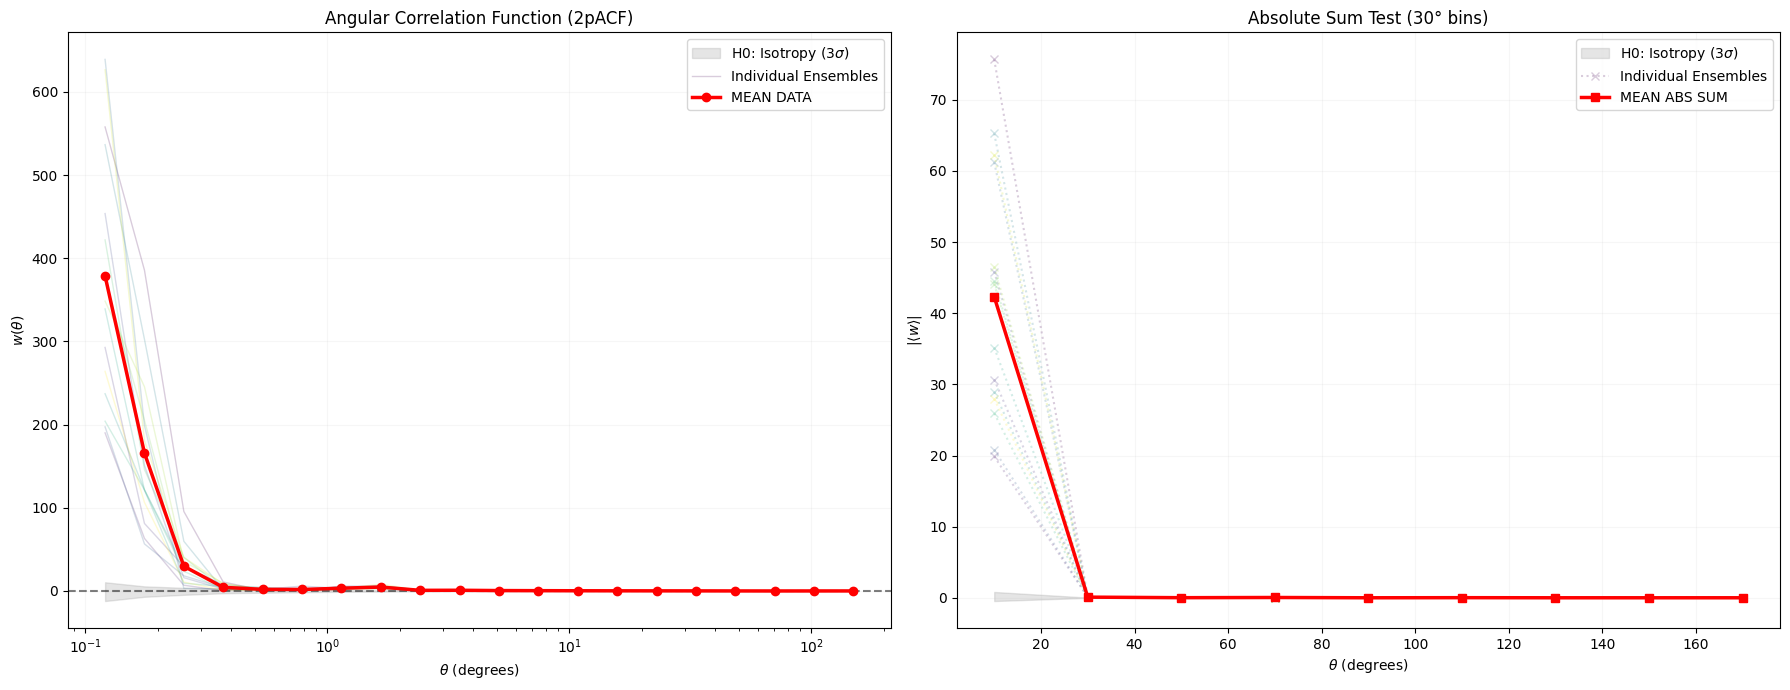

In [10]:
# ==============================================================
# Plotting
# ==============================================================

fig, ax = plt.subplots(1, 2, figsize=(18, 7))
colors = plt.cm.viridis(np.linspace(0, 1, 15))

# --- 2pACF ---
ax[0].fill_between(theta,
                   h0_median - 3*h0_std,
                   h0_median + 3*h0_std,
                   color='gray', alpha=0.2,
                   label=r'H0: Isotropy ($3\sigma$)')

for i in range(15):
    lbl = "Individual Ensembles" if i == 0 else ""
    ax[0].plot(theta, all_w_obs[i],
               color=colors[i], alpha=0.2, lw=1, label=lbl)

ax[0].plot(theta, mean_w,
           color='red', marker='o', lw=2.5,
           label='MEAN DATA', zorder=10)

ax[0].axhline(0, color='black', ls='--', alpha=0.5)
ax[0].set_xscale('log')
ax[0].set_xlabel(r'$\theta$ (degrees)')
ax[0].set_ylabel(r'$w(\theta)$')
ax[0].set_title('Angular Correlation Function (2pACF)')
ax[0].legend()
ax[0].grid(True, alpha=0.1)

# --- Absolute Sum ---
ax[1].fill_between(COARSE_CENTERS,
                   abs_h0_median - 3*abs_h0_std,
                   abs_h0_median + 3*abs_h0_std,
                   color='gray', alpha=0.2,
                   label=r'H0: Isotropy ($3\sigma$)')

for i in range(15):
    lbl = "Individual Ensembles" if i == 0 else ""
    ax[1].plot(COARSE_CENTERS, all_abs_obs[i],
               color=colors[i], alpha=0.2,
               marker='x', ls=':', label=lbl)

ax[1].plot(COARSE_CENTERS, mean_abs,
           color='red', marker='s', lw=2.5,
           label='MEAN ABS SUM', zorder=10)

ax[1].set_xlabel(r'$\theta$ (degrees)')
ax[1].set_ylabel(r'$|\langle w \rangle|$')
ax[1].set_title('Absolute Sum Test (30° bins)')
ax[1].legend()
ax[1].grid(True, alpha=0.1)

plt.tight_layout()
plt.savefig("2pACF_FRB_analysis_15cats.png", dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# ==============================================================
# Table output (Enhanced with statistical comparison)
# ==============================================================

# DataFrame com resultados individuais
df_abs_results = pd.DataFrame(
    all_abs_obs,
    columns=[f"{c:.0f} deg" for c in COARSE_CENTERS]
)

df_abs_results.index = [f"Comb_{i+1}" for i in range(15)]

print("\n--- Absolute Sum Test: Individual Realizations ---")
print(df_abs_results)


# ==============================================================
# Summary statistics vs H0
# ==============================================================

mean_obs = df_abs_results.mean()
std_obs  = df_abs_results.std()

summary_df = pd.DataFrame({
    "Mean Obs": mean_obs,
    "Std Obs": std_obs,
    "H0 Median": abs_h0_median,
    "H0 Std": abs_h0_std,
})

# --------------------------------------------------------------
# Significance (z-score)
# --------------------------------------------------------------

summary_df["Z-score"] = (summary_df["Mean Obs"] - summary_df["H0 Median"]) / summary_df["H0 Std"]

# Flag for significant deviations
summary_df["Significant (>3σ)"] = np.abs(summary_df["Z-score"]) > 3


# ==============================================================
# Output
# ==============================================================

print("\n--- Absolute Sum Test: Summary vs H0 ---")
print(summary_df.round(4))


# ==============================================================
# Optional: Global metric (very useful)
# ==============================================================

# Quadratic sum of z-scores (global anisotropy indicator)
global_chi2 = np.sum(summary_df["Z-score"]**2)
dof = len(summary_df)

print("\n--- Global Anisotropy Indicator ---")
print(f"Chi2 = {global_chi2:.2f} for {dof} bins")
print(f"Chi2/dof = {global_chi2/dof:.2f}")


--- Absolute Sum Test: Individual Realizations ---
            15 deg    45 deg    75 deg   105 deg  135 deg  165 deg
Comb_1   70.644109  0.048356  0.058146  0.013084      0.0      0.0
Comb_2   18.555020  0.040312  0.041685  0.011590      0.0      0.0
Comb_3   28.645374  0.054612  0.049917  0.021563      0.0      0.0
Comb_4   42.803736  0.042350  0.034253  0.014451      0.0      0.0
Comb_5   19.447897  0.033761  0.052375  0.011644      0.0      0.0
Comb_6   57.145177  0.024338  0.033804  0.015672      0.0      0.0
Comb_7   60.932030  0.051778  0.040511  0.023598      0.0      0.0
Comb_8   27.030106  0.033172  0.042417  0.009694      0.0      0.0
Comb_9   32.830263  0.045537  0.053329  0.014550      0.0      0.0
Comb_10  24.222263  0.023446  0.037427  0.009054      0.0      0.0
Comb_11  41.571702  0.054130  0.041548  0.018773      0.0      0.0
Comb_12  41.182027  0.020832  0.030477  0.014030      0.0      0.0
Comb_13  43.453437  0.007020  0.028087  0.016514      0.0      0.0
Comb_14  5